Data Summary:
           Index       Price       Stock           EAN  Internal ID
count  68.000000   68.000000   68.000000  6.800000e+01    68.000000
mean   52.205882  469.058824  540.602941  4.979743e+12    49.823529
std    28.546144  277.564992  277.318565  2.875042e+12    27.493251
min     2.000000    1.000000   10.000000  5.246382e+08     3.000000
25%    27.750000  251.250000  324.500000  2.769721e+12    28.250000
50%    53.000000  431.500000  575.500000  4.884281e+12    47.500000
75%    77.500000  679.000000  764.250000  7.676943e+12    74.500000
max    98.000000  998.000000  998.000000  9.921752e+12    99.000000

Batch GD Final Parameters: theta0=nan, theta1=nan


c:\Users\Surajj M\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Surajj M\AppData\Local\Temp\ipykernel_24864\3151034272.py:46: RuntimeWarning: overflow encountered in square
  cost = ((error)**2).mean() / 2
c:\Users\Surajj M\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\Surajj M\AppData\Local\Temp\ipykernel_24864\3151034272.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  theta1 -= alpha * d_theta1


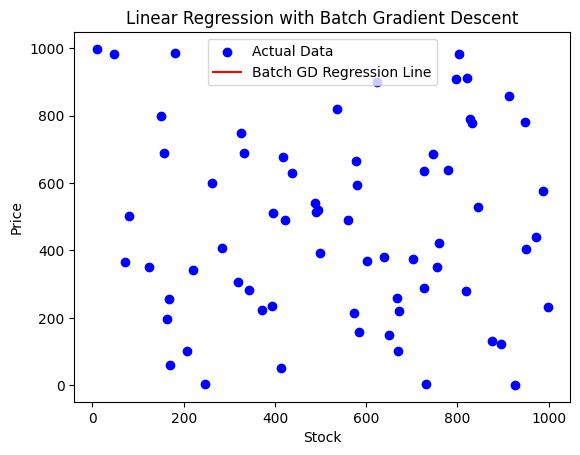

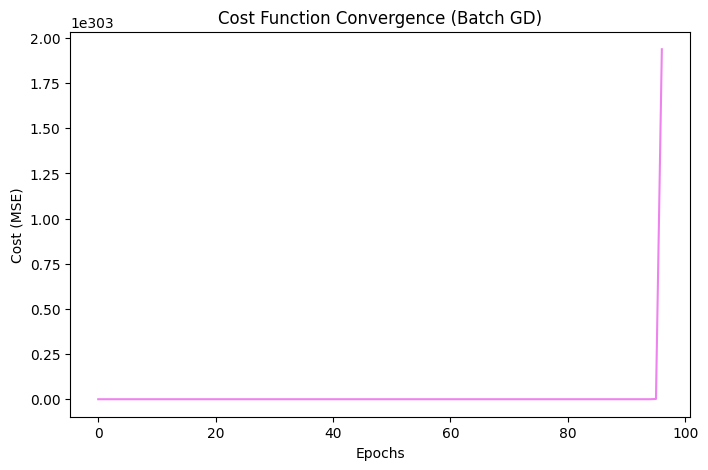


scikit-learn Parameters: intercept=480.9690, slope=-0.0220


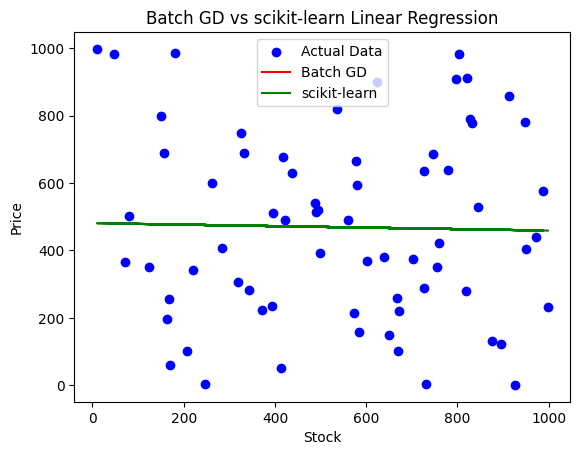

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Load and Clean Data
df = pd.read_csv(
    r'C:\Users\Surajj M\Documents\NumPy\Pandas\products-100.csv',
    engine='python',
    on_bad_lines='skip',
    skipinitialspace=True
)

# Strip whitespace from column names and string fields
df.columns = df.columns.str.strip()
df['Name'] = df['Name'].str.strip()
df['Category'] = df['Category'].str.strip()

print("Data Summary:")
print(df.describe())

# 2. Select Features
X = df["Stock"].values
y = df["Price"].values
m = len(X)

# 3. Batch Gradient Descent Implementation
theta0, theta1 = 0, 0   # Initial parameters
alpha = 0.0001          # Learning rate (small because prices may be large)
epochs = 1000
cost_history = []

for _ in range(epochs):
    y_pred = theta0 + theta1 * X
    error = y_pred - y
    
    # Gradients
    d_theta0 = (1/m) * error.sum()
    d_theta1 = (1/m) * (error * X).sum()
    
    # Update parameters
    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1
    
    # Track cost
    cost = ((error)**2).mean() / 2
    cost_history.append(cost)

print(f"\nBatch GD Final Parameters: theta0={theta0:.4f}, theta1={theta1:.4f}")

# 4. Visualization of Batch GD
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, theta0 + theta1 * X, color="red", label="Batch GD Regression Line")
plt.xlabel("Stock")
plt.ylabel("Price")
plt.title("Linear Regression with Batch Gradient Descent")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), cost_history, color="violet")
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Cost Function Convergence (Batch GD)")
plt.show()

# 5. Compare with scikit-learn Linear Regression
X_reshaped = X.reshape(-1, 1)  # sklearn expects 2D input
model = LinearRegression()
model.fit(X_reshaped, y)

print(f"\nscikit-learn Parameters: intercept={model.intercept_:.4f}, slope={model.coef_[0]:.4f}")

# Visualization of Comparison
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, theta0 + theta1 * X, color="red", label="Batch GD")
plt.plot(X, model.predict(X_reshaped), color="green", label="scikit-learn")
plt.xlabel("Stock")
plt.ylabel("Price")
plt.title("Batch GD vs scikit-learn Linear Regression")
plt.legend()
plt.show()
